In [1]:
import struct
import math
import time
import csv

import casadi as ca
import numpy as np
from matplotlib import pyplot as plt

from scipy.spatial.transform import Rotation as R
from ahrs.common.orientation import acc2q
from ahrs import Quaternion

from scipy.signal import butter, filtfilt, lfilter, lfilter_zi

In [14]:
'''Read raw values'''
from parse import Parser
import mc_common
import random

parser = Parser()
mc_x, mc_y = parser.read_mincopter_log('../../build-generic/mincopter_log.txt')

if False:
    for i,e in enumerate(mc_y.keys()):
        print(f'{e}: {len(mc_y[e])}')

Text(0.5, 1.0, 'Z-pos')

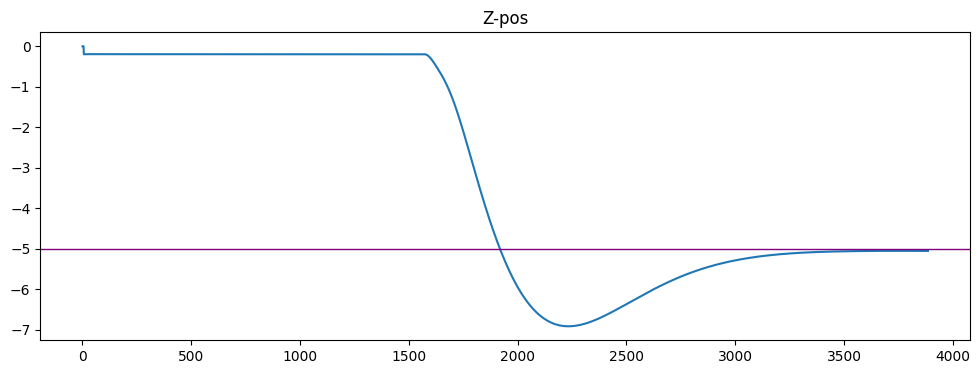

In [20]:
fig, ax = plt.subplots(1,1,figsize=(12,4))
ax.plot(mc_y['pos_z_a'])
ax.axhline(y=-5, color='purple', linewidth=1)
ax.set_title('Z-pos')

## Accelerometer Variances (at hover)

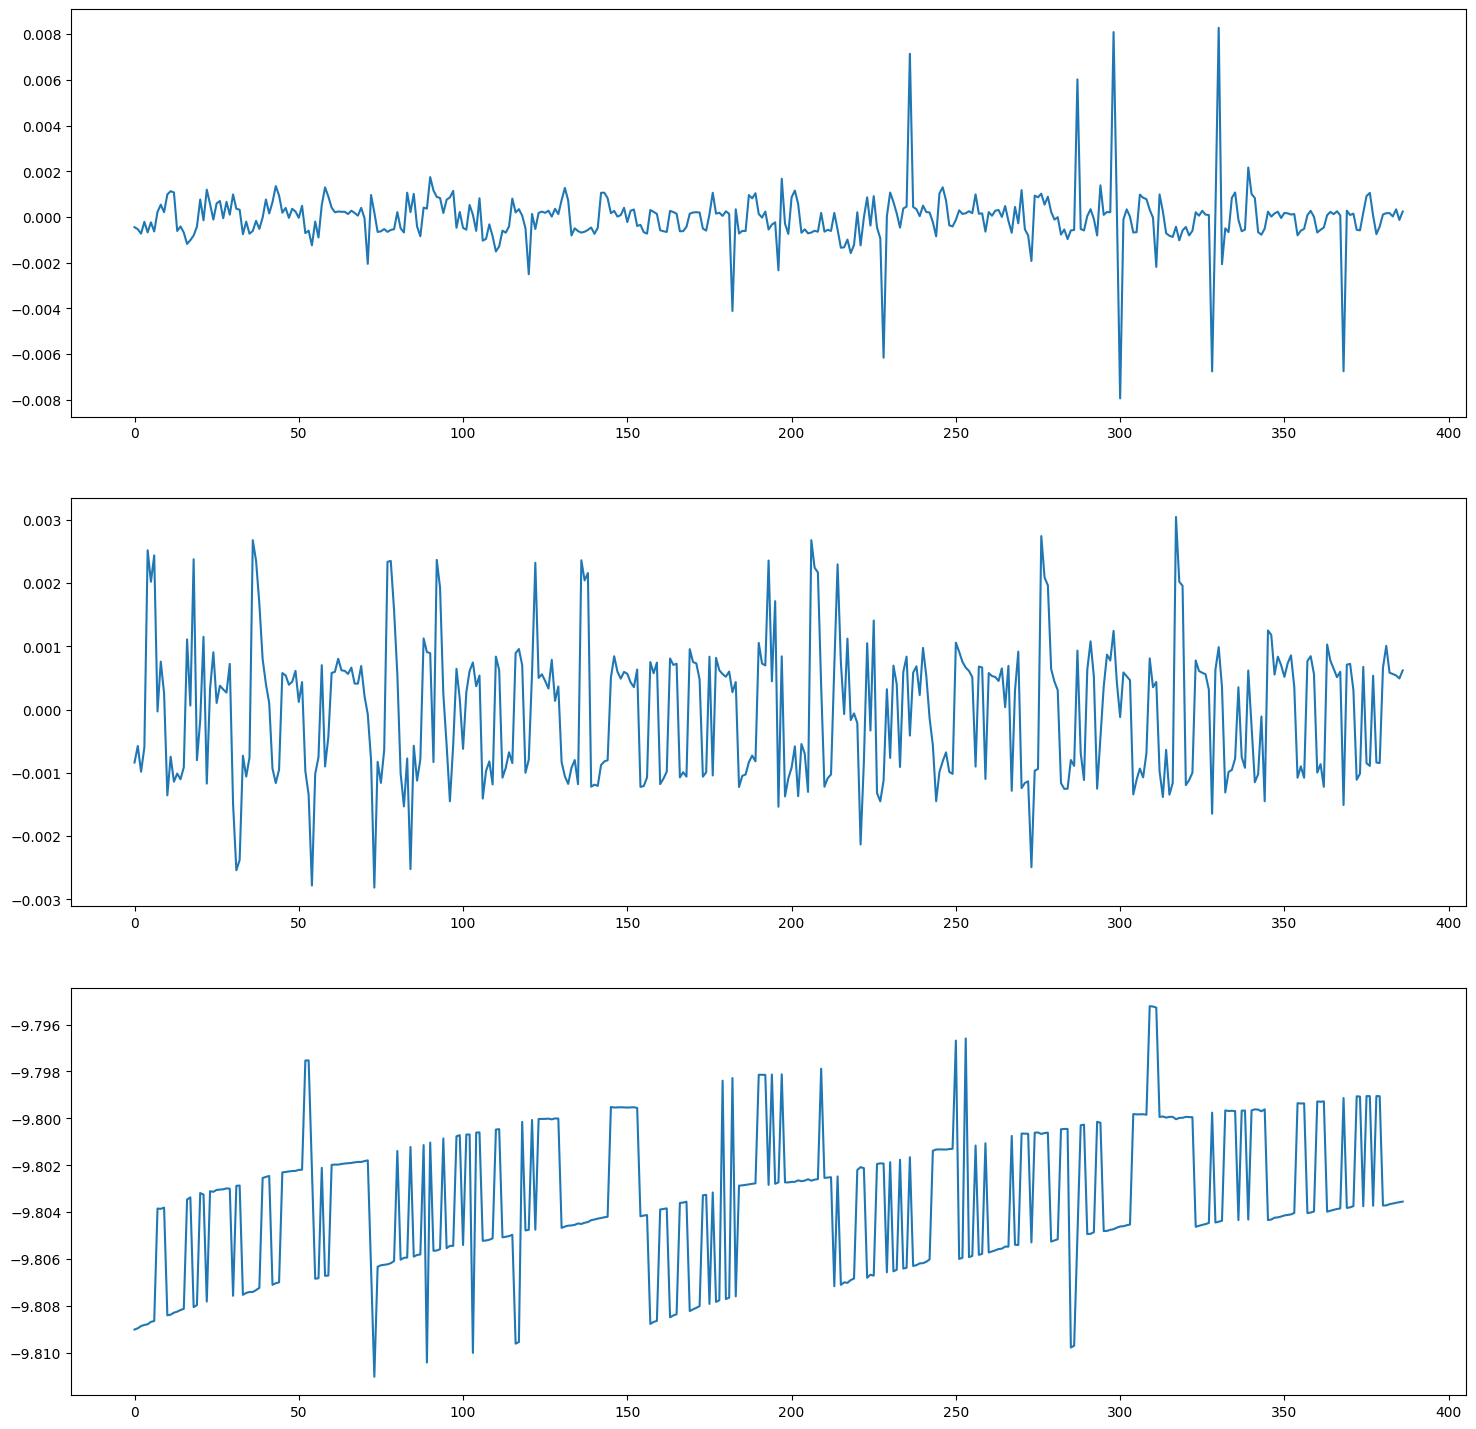

In [36]:
xmin = 3500
xmax = 4000
fig, ax = plt.subplots(3,1,figsize=(18,18))
ax[0].plot(mc_y['accel_x'][xmin:xmax])
ax[1].plot(mc_y['accel_y'][xmin:xmax])
ax[2].plot(mc_y['accel_z'][xmin:xmax])

In [41]:
from scipy.ndimage import standard_deviation, variance

target = [
    np.array(mc_y['accel_x'][xmin:xmax]),
    np.array(mc_y['accel_y'][xmin:xmax]),
    np.array(mc_y['accel_z'][xmin:xmax])]

accel_stddev = [ standard_deviation(t) for t in target]
accel_variance = [ variance(t) for t in target]
print(accel_stddev)
print(accel_variance)
print([np.average(i) for i in target])

[np.float64(0.0012512560155082263), np.float64(0.0010635589984816034), np.float64(0.00302281925575705)]
[np.float64(1.5656416163455226e-06), np.float64(1.1311577432511912e-06), np.float64(9.137436252975606e-06)]
[np.float64(-3.568031261367759e-05), np.float64(-9.14804486009456e-06), np.float64(-9.803437225578367)]


## Gyrometer Variances (at hover)

In [38]:
from scipy.ndimage import standard_deviation, variance

target = [
    np.array(mc_y['gyro_x'][xmin:xmax]),
    np.array(mc_y['gyro_y'][xmin:xmax]),
    np.array(mc_y['gyro_z'][xmin:xmax])]

accel_stddev = [ standard_deviation(t) for t in target]
accel_variance = [ variance(t) for t in target]
print(accel_stddev)
print(accel_variance)

[np.float64(0.001831761939806953), np.float64(0.0027534925322894163), np.float64(0.004545235426558022)]
[np.float64(3.355351804125332e-06), np.float64(7.581721125373582e-06), np.float64(2.065916508283809e-05)]
